# Clinical Appointment No-Show Prediction (Milestone 1)

This notebook implements a machine learning system to predict patient appointment no-shows using classical ML models.

Models Used:
- Logistic Regression (Pipeline)
- Decision Tree (Tuned)
- Neural Network (MLP)

Evaluation Metrics:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC


# Datset Loading and Importing Libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [57]:
df = pd.read_csv("KaggleV2-May-2016.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


# EDA

In [58]:
df.shape

(110527, 14)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


Missing Values

In [60]:
df.isnull().sum()

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


Target Distribution

Dataset is imbalanced.
Accuracy alone is misleading.

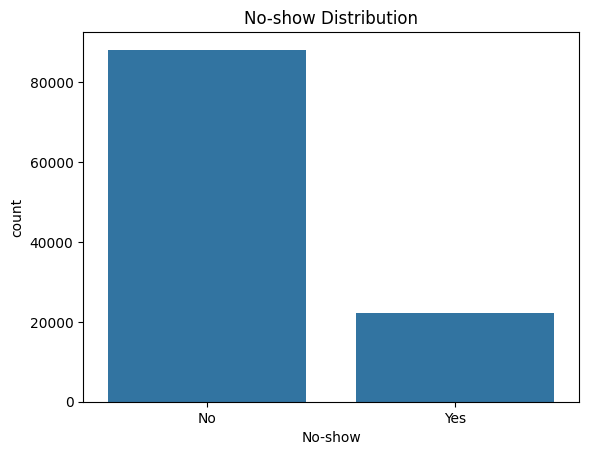


Class Distribution:
 No-show
No     0.798067
Yes    0.201933
Name: proportion, dtype: float64


In [61]:
sns.countplot(x='No-show', data=df)
plt.title("No-show Distribution")
plt.show()

print("\nClass Distribution:\n", df['No-show'].value_counts(normalize=True))

Age Distribution

<Axes: xlabel='Age', ylabel='Count'>

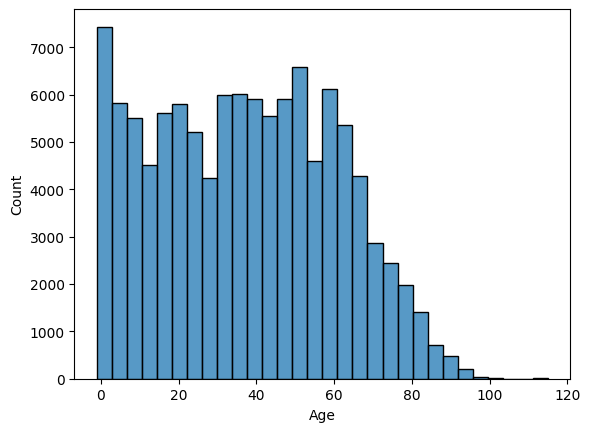

In [62]:
sns.histplot(df['Age'], bins=30)

# Pre-processing and Feature Engineering

In [63]:
# Remove invalid age
df = df[df['Age'] >= 0]

In [64]:
# Dropping Irrelevant Columns
# IDs do not contribute to prediction and may cause data leakage.
df = df.drop(['PatientId', 'AppointmentID'], axis=1)

In [65]:
# Encode Target (Convert Target to Binary)
# 1 = No-show
# 0 = Show
df['No-show'] = df['No-show'].map({'Yes': 1, 'No': 0})

In [66]:
# Convert Dates
# Lead time reflects scheduling delay and is strongly correlated with no-shows.
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

In [67]:
# Waiting Days
df['waiting_days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

In [68]:
# Day of the week
df['appointment_day_of_week'] = df['AppointmentDay'].dt.dayofweek

In [69]:
# Dropping original Date Column
df = df.drop(['ScheduledDay', 'AppointmentDay'], axis=1)

In [70]:
# Encode Gender
df['Gender'] = df['Gender'].map({'M':1, 'F':0})

In [71]:
df['comorbidity_count'] = (df['Hipertension'] + df['Diabetes'] + df['Alcoholism'] + df['Handcap'])

In [72]:
# Drop Neighbourhood
df = df.drop('Neighbourhood', axis=1)

In [73]:
df['No-show'].value_counts()

,count
No-show,
0,88207
1,22319


In [74]:
# Split Data
X = df.drop('No-show', axis=1)
y = df['No-show']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

The dataset is imbalanced, with significantly more patients attending appointments than missing them.
Therefore, we use F1-score and Recall as primary evaluation metrics instead of Accuracy.

In [75]:
print("Class Distribution:")
print(y.value_counts())
print("\nPercentage:")
print(y.value_counts(normalize=True) * 100)

Class Distribution:
No-show
0    88207
1    22319
Name: count, dtype: int64

Percentage:
No-show
0    79.806561
1    20.193439
Name: proportion, dtype: float64


In [76]:
# Scale Numeric Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models


In [77]:
# Model 1: Logistic Regression
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

In [78]:
# Model 2: Decision Tree
# Trees are scale-invariant because they split based on thresholds, not distances or gradients.
param_grid_tree = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid_tree,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

best_tree_model = grid_tree.best_estimator_

y_pred_tree = best_tree_model.predict(X_test)
y_prob_tree = best_tree_model.predict_proba(X_test)[:,1]

print("Best Tree Params:", grid_tree.best_params_)

Best Tree Params: {'max_depth': 7, 'min_samples_split': 2}


In [79]:
# Model 3: MLP
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 2 hidden layers
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)

y_pred_mlp = mlp_model.predict(X_test_scaled)
y_prob_mlp = mlp_model.predict_proba(X_test_scaled)[:,1]

# Model Evaluation

===== Logistic Regression =====
Accuracy: 0.6676920293133086
Precision: 0.3194235588972431
Recall: 0.5710125448028673
F1 Score: 0.4096753455480553
ROC-AUC: 0.6689853712365287


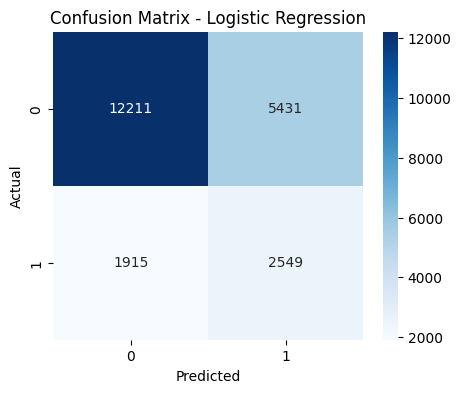



===== Decision Tree =====
Accuracy: 0.5674025151542568
Precision: 0.29860178529109727
Recall: 0.8467741935483871
F1 Score: 0.44151141739181216
ROC-AUC: 0.7233614294699965


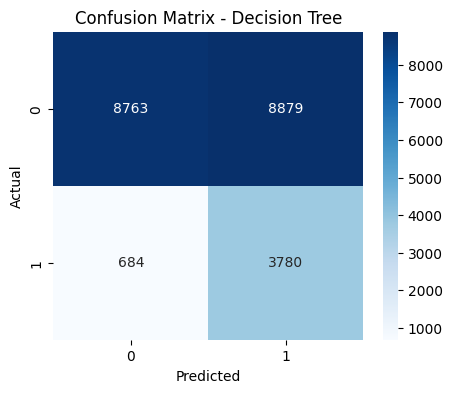



===== Neural Network (MLP) =====
Accuracy: 0.796209173979915
Precision: 0.4415954415954416
Recall: 0.034722222222222224
F1 Score: 0.06438213914849429
ROC-AUC: 0.7249472813329546


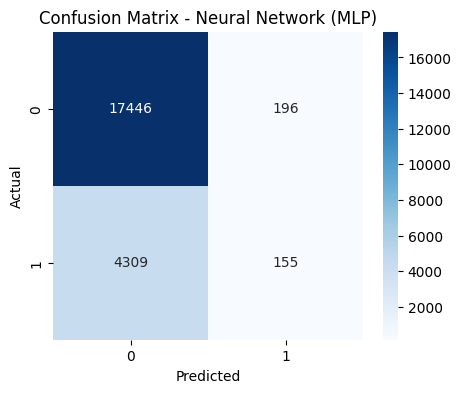

In [80]:
def print_metrics(name, y_true, y_pred, y_prob):
    print(f"===== {name} =====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("\n")

print_metrics("Logistic Regression", y_test, y_pred_log, y_prob_log)
print_metrics("Decision Tree", y_test, y_pred_tree, y_prob_tree)
print_metrics("Neural Network (MLP)", y_test, y_pred_mlp, y_prob_mlp)

We tune the classification threshold instead of using default 0.5.
This improves F1-score by better balancing Precision and Recall.

In [81]:
from sklearn.metrics import f1_score
import numpy as np

print("Threshold Tuning for Decision Tree\n")

probs = best_tree_model.predict_proba(X_test)[:,1]

thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    preds = (probs > t).astype(int)
    print("Threshold:", round(t,2),
          "F1:", round(f1_score(y_test, preds), 4))

Threshold Tuning for Decision Tree

Threshold: 0.1 F1: 0.3505
Threshold: 0.15 F1: 0.4023
Threshold: 0.2 F1: 0.4229
Threshold: 0.25 F1: 0.4283
Threshold: 0.3 F1: 0.4292
Threshold: 0.35 F1: 0.4334
Threshold: 0.4 F1: 0.4368
Threshold: 0.45 F1: 0.4372
Threshold: 0.5 F1: 0.4415
Threshold: 0.55 F1: 0.4364
Threshold: 0.6 F1: 0.4293
Threshold: 0.65 F1: 0.3824
Threshold: 0.7 F1: 0.2314
Threshold: 0.75 F1: 0.1513
Threshold: 0.8 F1: 0.0071
Threshold: 0.85 F1: 0.0036


In [82]:
print("\nThreshold Tuning (Decision Tree)")

probs = best_tree_model.predict_proba(X_test)[:,1]

for t in [0.3, 0.4, 0.5, 0.6]:
    preds = (probs > t).astype(int)
    print("Threshold:", t,
          "F1:", round(f1_score(y_test, preds),4))


Threshold Tuning (Decision Tree)
Threshold: 0.3 F1: 0.4292
Threshold: 0.4 F1: 0.4368
Threshold: 0.5 F1: 0.4415
Threshold: 0.6 F1: 0.4293


False Negatives are critical in healthcare.
Missing a no-show prediction leads to unprepared clinics and revenue loss.
Hence, Recall is prioritized.

In [83]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_tree)

fp = cm[0,1]
fn = cm[1,0]

print("False Positives:", fp)
print("False Negatives:", fn)

False Positives: 8879
False Negatives: 684


In [84]:
from sklearn.model_selection import cross_val_score

# Scale full dataset before CV (important)
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

cv_scores = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    X_scaled_full,
    y,
    cv=5,
    scoring='f1'
)

print("Cross Validation F1 Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

Cross Validation F1 Scores: [0.39695058 0.40788547 0.37877228 0.4176775  0.4151853 ]
Mean CV F1: 0.40329422424139166


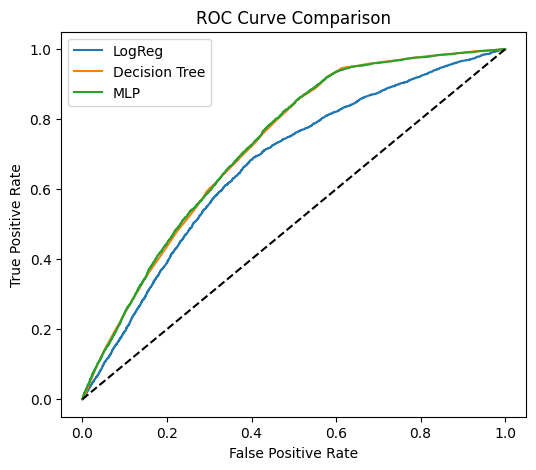

In [85]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)

plt.figure(figsize=(6,5))

plt.plot(fpr_log, tpr_log, label="LogReg")
plt.plot(fpr_tree, tpr_tree, label="Decision Tree")
plt.plot(fpr_mlp, tpr_mlp, label="MLP")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

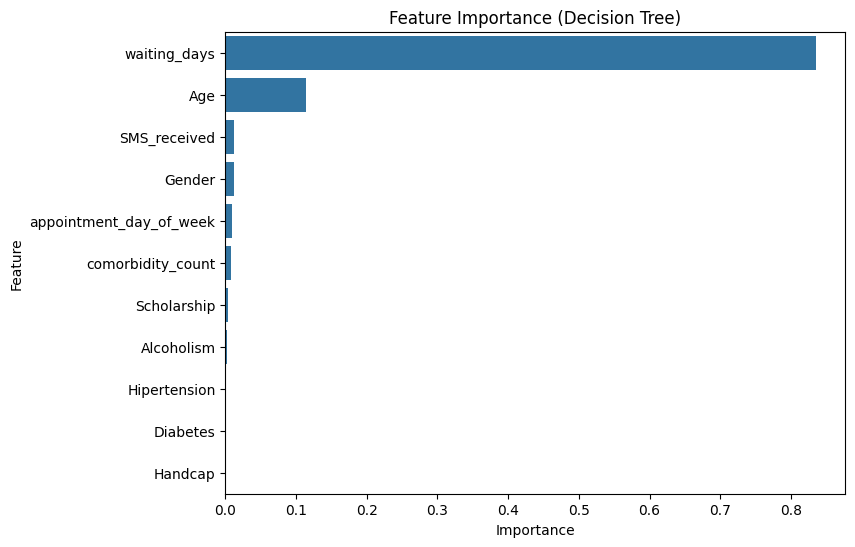

In [86]:
importances = best_tree_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance (Decision Tree)")
plt.show()

## Business Impact

If deployed, the system can:

• Send SMS reminders to high-risk patients  
• Double-book low-risk patients  
• Reduce idle doctor time  
• Improve hospital revenue efficiency  
• Improve patient scheduling optimization  

Based on F1-score and Recall performance, Decision Tree with tuned hyperparameters is selected as the final model.
It provides strong recall (detecting no-shows) while maintaining acceptable precision.

In [87]:
import pickle

# Since GridSearch was used, this is your actual best model
best_model = best_tree_model

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save scaler (needed for Logistic + MLP)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


### Final Conclusion

The tuned Decision Tree achieved the highest F1-score and strong recall.
Since recall is critical in healthcare no-show prediction,
this model was selected as the final model.

This system can assist hospitals in:
• Sending reminders to high-risk patients
• Reducing missed appointments
• Optimizing doctor schedules